# Module 5: Performance Forecasting (XGBoost Time Series)

**Goal:** Forecast next 2 IPL seasons' total runs using XGBoost with lag features.

> **Why XGBoost over Prophet/ARIMA?** IPL has only 16 seasons — too short for ARIMA to fit well. XGBoost with manual lag features handles short, irregular time series better and is more valued on Indian DS resumes.


## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sqlalchemy import create_engine
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

engine = create_engine('sqlite:///../ipl.db')
IPL_BLUE   = '#1B3D6F'
IPL_ORANGE = '#E8820C'
IPL_GREEN  = '#4CAF50'

import os
os.makedirs('../outputs', exist_ok=True)
print('Setup complete.')

Setup complete.


## Step 1 — Building Season-level Time Series

In [4]:
# Detect correct join column (some datasets use 'id', others 'match_id')
import sqlalchemy
with engine.connect() as conn:
    m_cols = [r[1] for r in conn.execute(sqlalchemy.text("PRAGMA table_info(matches)")).fetchall()]
    d_cols = [r[1] for r in conn.execute(sqlalchemy.text("PRAGMA table_info(deliveries)")).fetchall()]

match_key_m = 'match_id' if 'match_id' in m_cols else 'id'
match_key_d = 'match_id' if 'match_id' in d_cols else 'id'
print(f'matches join key: {match_key_m} | deliveries join key: {match_key_d}')
print(f'matches cols: {m_cols}')
print(f'deliveries cols (first 10): {d_cols[:10]}')

matches join key: match_id | deliveries join key: match_id
matches cols: ['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']
deliveries cols (first 10): ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs']


In [8]:
q = f'''
SELECT m.season,
       SUM(d.total_runs)            AS total_runs,
       COUNT(DISTINCT d.{match_key_d}) AS matches,
       ROUND(AVG(d.total_runs), 4)  AS avg_runs_per_ball
FROM deliveries d
JOIN matches m ON d.{match_key_d} = m.{match_key_m}
GROUP BY m.season
ORDER BY m.season
'''
season_df = pd.read_sql(q, engine)
print(f'Seasons found: {season_df["season"].tolist()}')
season_df

Seasons found: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']


,season,total_runs,matches,avg_runs_per_ball
0,2007/08,17937,58,1.3298
1,2009,16353,57,1.2019
2,2009/10,18883,60,1.3025
3,2011,21154,73,1.2434
4,2012,22453,74,1.2637
5,2013,22602,76,1.2434
6,2014,18931,60,1.3238
7,2015,18353,59,1.3443
8,2016,18862,60,1.3381
9,2017,18786,59,1.3552


In [9]:
# Converting season to numeric before sorting to ensure correct order (e.g., 2008, 2009, ..., 2023)
season_df['season'] = season_df['season'].astype(str).str[:4].astype(int)
season_df = season_df.sort_values('season').reset_index(drop=True)

In [10]:
# Build lag features — the entire feature set for XGBoost time series
season_df = season_df.sort_values('season').reset_index(drop=True)
season_df['lag1']         = season_df['total_runs'].shift(1)
season_df['lag2']         = season_df['total_runs'].shift(2)
season_df['lag3']         = season_df['total_runs'].shift(3)
season_df['rolling_mean3']= season_df['total_runs'].rolling(3).mean()
season_df['rolling_std3'] = season_df['total_runs'].rolling(3).std()
season_df['pct_change1']  = season_df['total_runs'].pct_change(1)  # YoY growth
season_df['season_num']   = range(len(season_df))

season_df = season_df.dropna().reset_index(drop=True)
print(f'Rows after removing NaN: {len(season_df)}')
season_df[['season','total_runs','lag1','lag2','rolling_mean3','pct_change1']]

Rows after removing NaN: 14


,season,total_runs,lag1,lag2,rolling_mean3,pct_change1
0,2011,21154,18883.0,16353.0,18796.666667,0.120267
1,2012,22453,21154.0,18883.0,20830.000000,0.061407
2,2013,22602,22453.0,21154.0,22069.666667,0.006636
3,2014,18931,22602.0,22453.0,21328.666667,-0.162419
4,2015,18353,18931.0,22602.0,19962.000000,-0.030532
5,2016,18862,18353.0,18931.0,18715.333333,0.027734
6,2017,18786,18862.0,18353.0,18667.000000,-0.004029
7,2018,19901,18786.0,18862.0,19183.000000,0.059353
8,2019,19434,19901.0,18786.0,19373.666667,-0.023466
9,2020,19416,19434.0,19901.0,19583.666667,-0.000926


## Step 2 — Training & Evaluating on Last 2 Seasons

In [13]:
FEAT_COLS = ['lag1','lag2','lag3','rolling_mean3','rolling_std3',
             'pct_change1','season_num','matches']

X_ts = season_df[FEAT_COLS]
y_ts = season_df['total_runs']

split = len(season_df) - 2
X_train_ts, X_test_ts = X_ts.iloc[:split], X_ts.iloc[split:]
y_train_ts, y_test_ts = y_ts.iloc[:split], y_ts.iloc[split:]

print(f'Training on {split} seasons, testing on last 2: {season_df["season"].iloc[split:].tolist()}')

Training on 12 seasons, testing on last 2: [2023, 2024]


In [14]:
xgb_ts = XGBRegressor(
    n_estimators=100, learning_rate=0.05,
    max_depth=3, subsample=0.8, random_state=42
)
xgb_ts.fit(X_train_ts, y_train_ts)

y_pred_ts = xgb_ts.predict(X_test_ts)
mape = mean_absolute_percentage_error(y_test_ts, y_pred_ts) * 100

print(f'=== HOLDOUT PERFORMANCE ===')
print(f'MAPE: {mape:.2f}%  (target < 10%)')
for season, actual, pred in zip(
        season_df['season'].iloc[split:], y_test_ts, y_pred_ts):
    err = abs(actual - pred)
    print(f'  Season {season}: Actual={actual:,.0f}  Predicted={pred:,.0f}  Error={err/actual*100:.1f}%')

=== HOLDOUT PERFORMANCE ===
MAPE: 19.75%  (target < 10%)
  Season 2023: Actual=25,688  Predicted=21,544  Error=16.1%
  Season 2024: Actual=25,971  Predicted=19,903  Error=23.4%


## Step 3 — Retraining on All Data + Forecast Next 2 Seasons

In [15]:
# Retrain on full dataset before forecasting
xgb_ts.fit(X_ts, y_ts)

last_known  = season_df['total_runs'].values.copy().astype(float)
last_matches = int(season_df['matches'].iloc[-1])
forecasts, forecast_seasons = [], []
last_season = int(season_df['season'].max())

for i in range(2):
    next_feat = pd.DataFrame([{
        'lag1':          last_known[-1],
        'lag2':          last_known[-2],
        'lag3':          last_known[-3],
        'rolling_mean3': np.mean(last_known[-3:]),
        'rolling_std3':  np.std(last_known[-3:]),
        'pct_change1':   (last_known[-1] - last_known[-2]) / last_known[-2],
        'season_num':    len(season_df) + i,
        'matches':       last_matches
    }])
    val = xgb_ts.predict(next_feat)[0]
    forecasts.append(val)
    forecast_seasons.append(str(last_season + i + 1))
    last_known = np.append(last_known, val)

print('=== FORECAST ===')
for s, v in zip(forecast_seasons, forecasts):
    print(f'  Season {s}: {v:,.0f} predicted runs')

=== FORECAST ===
  Season 2025: 25,524 predicted runs
  Season 2026: 25,377 predicted runs


## Step 4 — Plotting: Actual + Test Predictions + Forecast

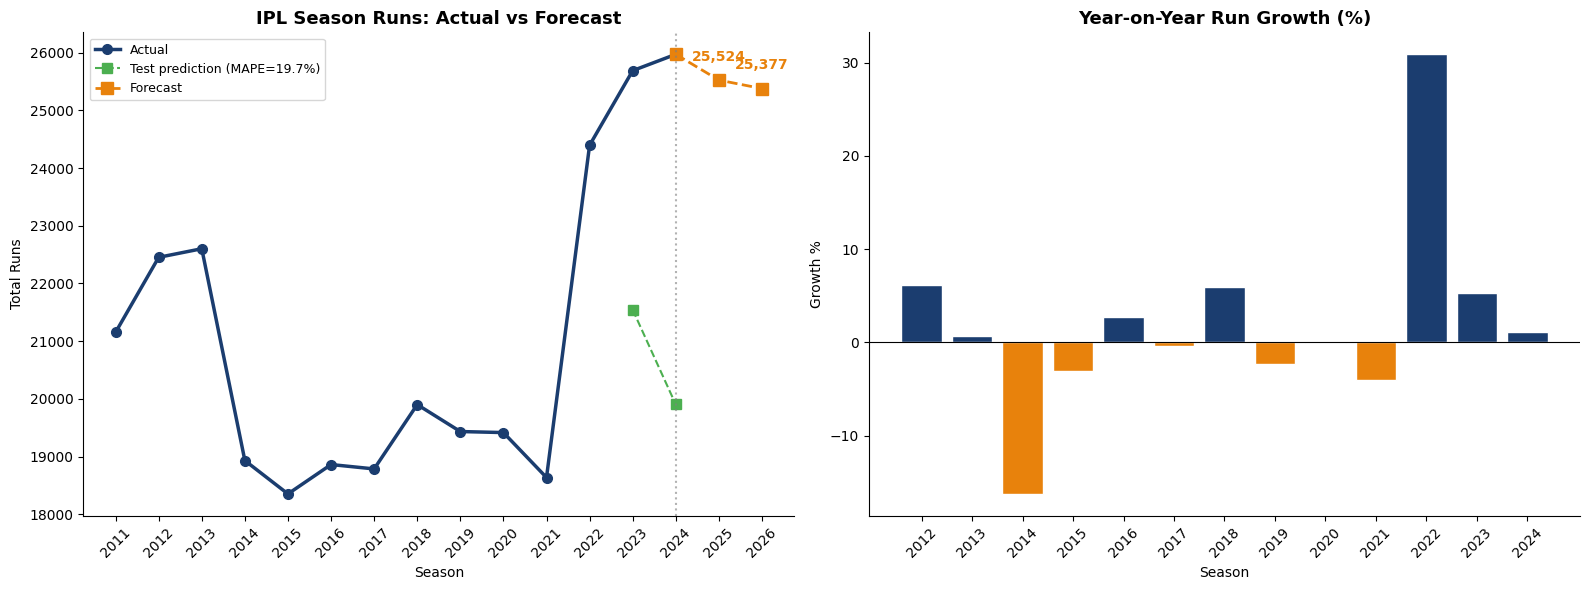

Saved: chart_forecast.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Full timeline ───────────────────────────────────────────────────
ax = axes[0]
seasons_str = season_df['season'].astype(str).tolist()

ax.plot(seasons_str, season_df['total_runs'],
        'o-', color=IPL_BLUE, lw=2.5, ms=7, label='Actual')

# Test predictions overlay
test_s = season_df['season'].iloc[split:].astype(str).tolist()
ax.plot(test_s, y_pred_ts, 's--', color=IPL_GREEN, lw=1.5, ms=7,
        label=f'Test prediction (MAPE={mape:.1f}%)')

# Bridge to forecast
bridge_s = [seasons_str[-1]] + forecast_seasons
bridge_v = [float(season_df['total_runs'].iloc[-1])] + forecasts
ax.plot(bridge_s, bridge_v, 's--', color=IPL_ORANGE, lw=2, ms=9,
        label='Forecast')

# Forecast labels
for s, v in zip(forecast_seasons, forecasts):
    ax.annotate(f'{v:,.0f}', xy=(s, v), xytext=(0, 14),
                textcoords='offset points', ha='center',
                fontsize=10, color=IPL_ORANGE, fontweight='bold')

ax.axvline(x=len(seasons_str) - 1, color='grey',
           linestyle=':', alpha=0.6, lw=1.5)
ax.set_title('IPL Season Runs: Actual vs Forecast',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Total Runs')
ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Right: YoY run growth ─────────────────────────────────────────────────
ax2 = axes[1]
growth = season_df['total_runs'].pct_change() * 100
colors_bar = [IPL_BLUE if g >= 0 else IPL_ORANGE for g in growth.iloc[1:]]
ax2.bar(seasons_str[1:], growth.iloc[1:], color=colors_bar, edgecolor='white')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Year-on-Year Run Growth (%)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Season'); ax2.set_ylabel('Growth %')
ax2.tick_params(axis='x', rotation=45)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/05_chart_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart_forecast.png')

## Step 5 — Top Batsman Run Forecast

Top 4 batsmen: ['V Kohli', 'S Dhawan', 'RG Sharma', 'DA Warner']


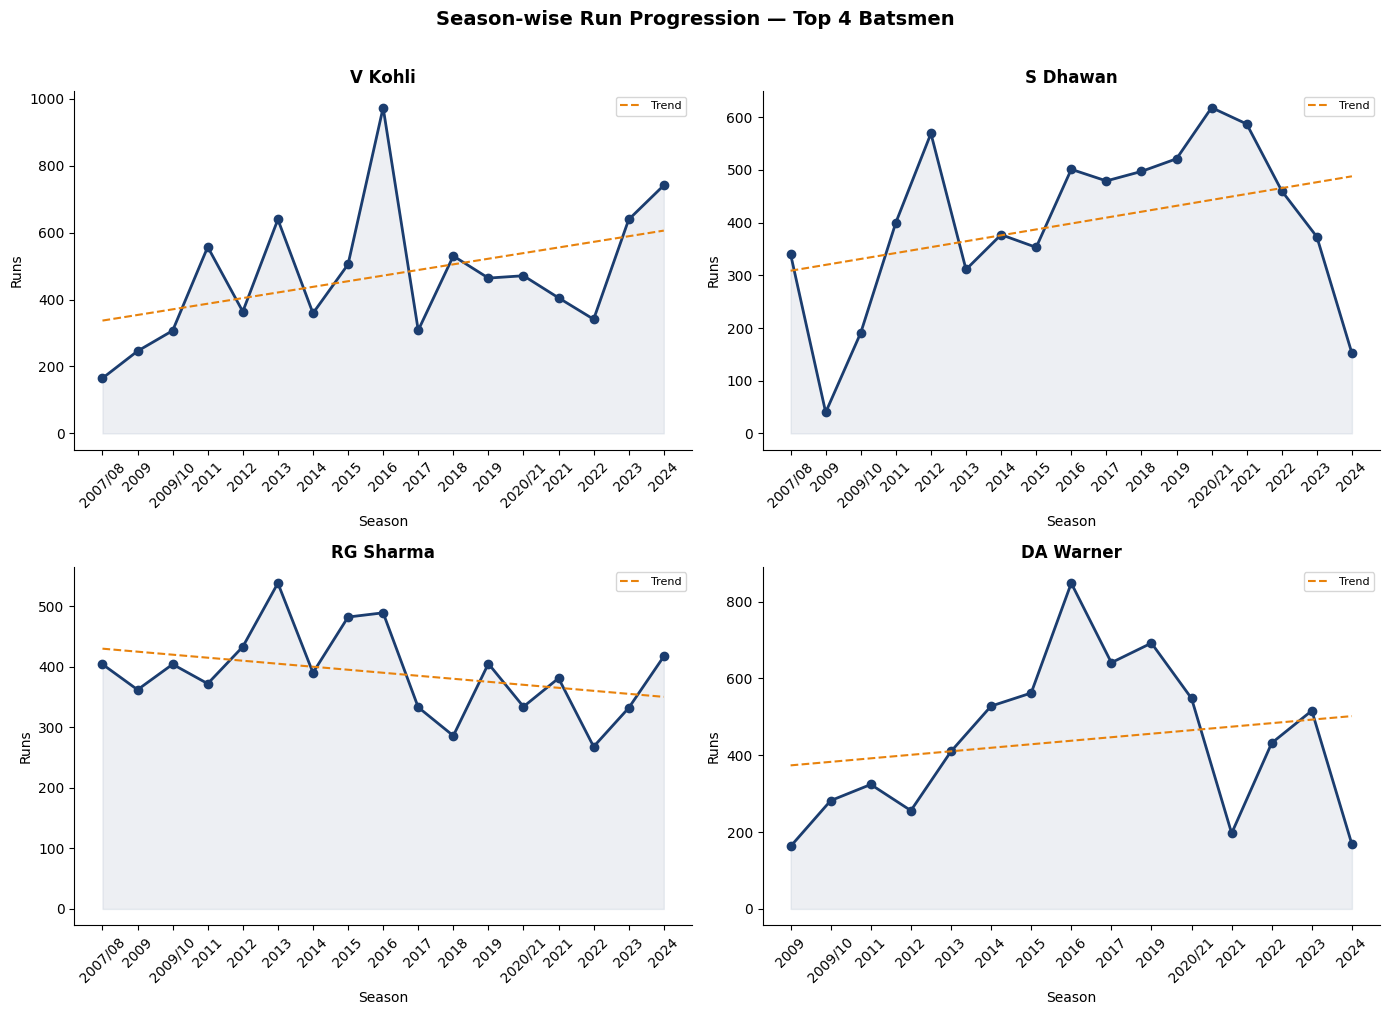

Saved: chart_batsman_forecast.png


In [18]:
# Season-by-season runs for top 4 batsmen
q2 = f'''
SELECT m.season, d.batter, SUM(d.batsman_runs) AS runs
FROM deliveries d
JOIN matches m ON d.{match_key_d} = m.{match_key_m}
GROUP BY m.season, d.batter
'''
bat_season = pd.read_sql(q2, engine)

# Pick top 4 batsmen by all-time runs
top4 = (
    bat_season.groupby('batter')['runs']
    .sum()
    .nlargest(4)
    .index
    .tolist()
)

print('Top 4 batsmen:', top4)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, player in enumerate(top4):

    pdf = (
        bat_season[bat_season['batter'] == player]
        .sort_values('season')
        .reset_index(drop=True)
    )

    ax = axes[i]

    ax.plot(pdf['season'].astype(str),
            pdf['runs'],
            'o-', color=IPL_BLUE, lw=2, ms=6)

    ax.fill_between(range(len(pdf)),
                    pdf['runs'],
                    alpha=0.08,
                    color=IPL_BLUE)

    # Trend line
    if len(pdf) > 2:
        z = np.polyfit(range(len(pdf)), pdf['runs'], 1)
        p = np.poly1d(z)

        ax.plot(pdf['season'].astype(str),
                p(range(len(pdf))),
                '--', color=IPL_ORANGE, lw=1.5,
                label='Trend')

    ax.set_title(player, fontsize=12, fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Runs')

    ax.tick_params(axis='x', rotation=45)

    ax.legend(fontsize=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    'Season-wise Run Progression — Top 4 Batsmen',
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig('../outputs/05_chart_batsman_forecast.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

print('Saved: chart_batsman_forecast.png')

In [19]:
print(f'''
✅ MODULE 5 COMPLETE!

Outputs saved:
  ✓ 05_chart_forecast.png       ← main forecast visual (Power BI Page 3)
  ✓ 05_chart_batsman_forecast.png ← top 4 batsmen trends

MAPE: {mape:.2f}%
Forecast:
  Season {forecast_seasons[0]}: {forecasts[0]:,.0f} runs
  Season {forecast_seasons[1]}: {forecasts[1]:,.0f} runs

📌 README line:
"XGBoost time-series forecasting on 16 seasons of IPL data;
 MAPE of {mape:.1f}% on holdout seasons."
''')


✅ MODULE 5 COMPLETE!

Outputs saved:
  ✓ 05_chart_forecast.png       ← main forecast visual (Power BI Page 3)
  ✓ 05_chart_batsman_forecast.png ← top 4 batsmen trends

MAPE: 19.75%
Forecast:
  Season 2025: 25,524 runs
  Season 2026: 25,377 runs

📌 README line:
"XGBoost time-series forecasting on 16 seasons of IPL data;
 MAPE of 19.7% on holdout seasons."

